In [8]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 245 ms, sys: 459 ms, total: 703 ms
Wall time: 2.36 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

In [3]:
# summarize number of isoforms per cluster
transcript_read_threshold = 10 # minimum number of counts per cluster

results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    tmp = adata[group.index, :].copy()
    var = tmp.var.copy()

    # get the transcripts
    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var = var[var['gene_type'] == 'protein_coding']
    var = var[var['transcript_type'] == 'protein_coding']
    var['transcript_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    
    var = var.groupby('gene_name')['transcript_pass'].sum()
    var = var.map(lambda x: "NE" if x == 0 else "single" if x == 1 else "multi")
    var.name = group_name
    results.append(var)

# save sankey inputs
outpath = "/scratch/indikar_root/indikar1/shared_data/for_joshua/sankey_inputs.csv"
results = pd.concat(results, axis=1)
results = results.reset_index()
results.to_csv(outpath, index=False)
results.head()

,gene_name,C1,C2,C3,CLP,HSC,LMPP,intial,progenitors
0,A1BG,NE,NE,NE,NE,NE,NE,NE,NE
1,A1BG-AS1,NE,NE,NE,NE,NE,NE,NE,NE
2,A2M,single,single,single,NE,NE,NE,single,NE
3,A2M-AS1,NE,NE,NE,NE,NE,NE,NE,NE
4,A2ML1,NE,NE,NE,NE,single,single,NE,single


# Sankey Plot

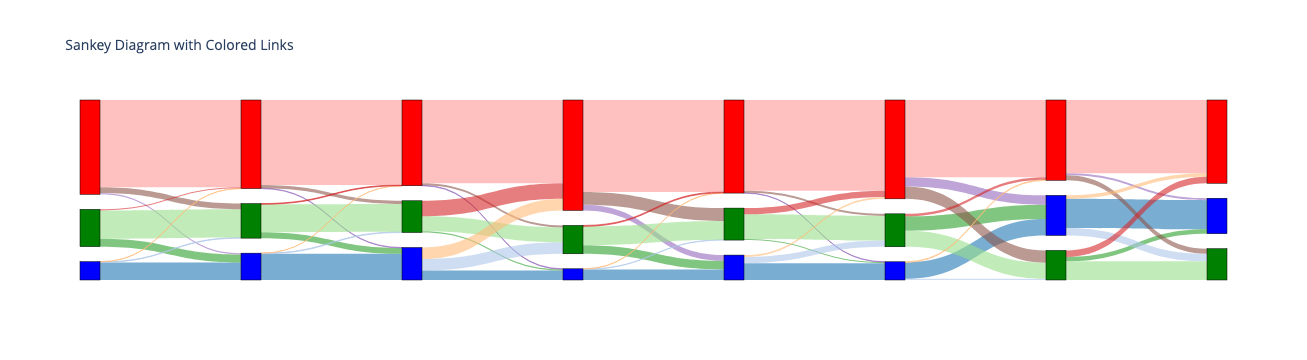

In [9]:
source, target, value, link_colors = [], [], [], []

# Define all possible transitions
transitions = ['multi', 'single', 'NE']
transition_index = {(from_t, to_t): i * 3 + j for i, from_t in enumerate(transitions) for j, to_t in enumerate(transitions)}
transition_colors = {
    ('multi', 'multi'): 'rgba(31, 119, 180, 0.6)',
    ('multi', 'single'): 'rgba(174, 199, 232, 0.6)',
    ('multi', 'NE'): 'rgba(255, 187, 120, 0.6)',
    ('single', 'multi'): 'rgba(44, 160, 44, 0.6)',
    ('single', 'single'): 'rgba(152, 223, 138, 0.6)',
    ('single', 'NE'): 'rgba(214, 39, 40, 0.6)',
    ('NE', 'multi'): 'rgba(148, 103, 189, 0.6)',
    ('NE', 'single'): 'rgba(140, 86, 75, 0.6)',
    ('NE', 'NE'): 'rgba(255, 152, 150, 0.6)'
}

for col in range(1, results.shape[1] - 1):
    s = [(col - 1) * 3 + i for i in range(3)] * 3
    t = sum([[col * 3 + i] * 3 for i in range(3)], [])

    source.extend(s)
    target.extend(t)

    # Count transitions
    counts = {k: 0 for k in transition_index}
    for from_val, to_val in zip(results.iloc[:, col], results.iloc[:, col + 1]):
        if from_val in transitions and to_val in transitions:
            counts[(from_val, to_val)] += 1

    # Fill values in the correct order
    for to_t in transitions:
        for from_t in transitions:
            value.append(counts[(from_t, to_t)])
            link_colors.append(transition_colors[(from_t, to_t)])

# Define node labels and colors
num_steps = results.shape[1] - 1
node_labels = sum([[f" " for label in transitions] for step in range(num_steps)], [])
node_colors = (['blue', 'green', 'red'] * num_steps)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(title_text="Sankey Diagram with Colored Links", font_size=10)
fig.show()

In [ ]:
break

raw pdf.shape=(29082, 9)
filtered pdf.shape=(15083, 9)
  gene_name      C1      C2      C3     CLP     HSC    LMPP  intial progenitors
0       A2M  single  single  single      NE      NE      NE  single          NE
1     A2ML1      NE      NE      NE      NE  single  single      NE      single
2    A4GALT      NE   multi   multi      NE      NE      NE   multi          NE
3     A4GNT      NE      NE  single      NE      NE      NE  single          NE
4      AAAS  single   multi   multi  single  single  single   multi       multi


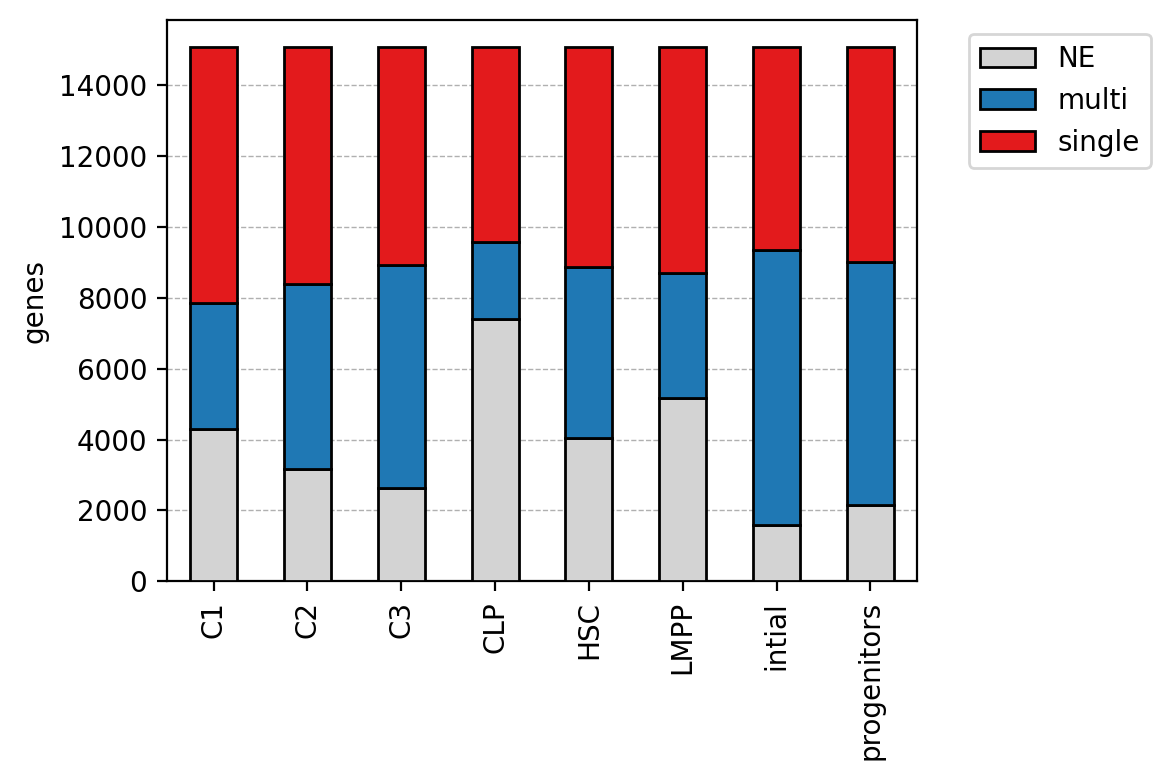

In [4]:
pdf = results.copy()
print(f"raw {pdf.shape=}")
mask = pdf.drop(columns="gene_name").ne("NE").any(axis=1)
pdf = pdf[mask].reset_index(drop=True)
print(f"filtered {pdf.shape=}")
print(pdf.head().to_string())

counts = pdf.drop(columns="gene_name").apply(pd.Series.value_counts).fillna(0).astype(int)
counts = counts.T

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 2.75

color = [
    '#d3d3d3',  # light grey for "NE"
    '#1f78b4',  # blue for "single"
    '#e31a1c', # red for "multi"
] 

# Plot
ax = counts.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 4),
    edgecolor='black',
    color=color,
    zorder=3
)

ax.set_ylabel("genes")
ax.set_xlabel("")
ax.legend(title="", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.show()

In [5]:
%%time
rsc.get.anndata_to_CPU(adata)

tdf = adata.to_df()
print(f"transcript dataframe: {tdf.shape=}")

adata.obs['n_transcripts'] = tdf.astype(bool).sum(axis=1)

tdf.columns = adata.var['gene_name']
tdf = tdf.groupby(level=0, axis=1).sum()
print(f"gene dataframe: {tdf.shape=}")

adata.obs['n_genes'] = tdf.astype(bool).sum(axis=1)

adata.obs.head()

transcript dataframe: tdf.shape=(21062, 113335)
gene dataframe: tdf.shape=(21062, 29082)
CPU times: user 48.8 s, sys: 18.8 s, total: 1min 7s
Wall time: 1min 7s


,dataset,dataset_bdata,source,cluster,group,label,filter_pass,bm_clusters,subgroup,n_transcripts,n_genes
AAACCAAAGGCGATCT-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,True,M16,progenitors,5200,4282
AAACCAAAGGTGAACG-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B4,bm_other,MEG/ERY,True,M17,progenitors,3188,2759
AAACCATTCCCTGTCA-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B3,bm_other,CMP,True,M11,progenitors,5042,4164
AAACCATTCCGCGATG-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B5,target,HSC,True,M11,HSC,2634,2327
AAACCATTCCTGTCGC-1-bone_marrow,bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,True,M11,progenitors,3346,2890


Text(0, 0.5, 'count')

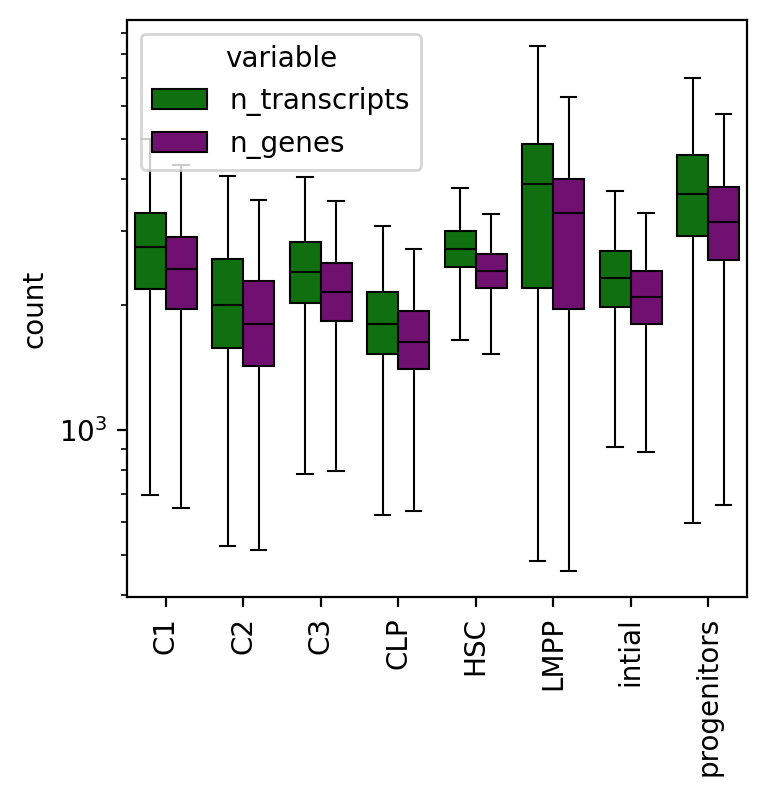

In [6]:
pdf = adata.obs.copy()
pdf = pd.melt(
    pdf, 
    id_vars='subgroup', 
    value_vars=['n_transcripts', 'n_genes'],
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3.75

sns.boxplot(
    data=pdf,
    x='subgroup',
    y='value',
    hue='variable',
    linewidth=0.75,
    linecolor='k',
    showfliers=False,
    palette=['green', 'purple'],    
)

plt.yscale("log")
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("count")

In [7]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# Prepare data
pdf = adata.obs.copy()
pdf = pd.melt(
    pdf, 
    id_vars='subgroup', 
    value_vars=['n_transcripts', 'n_genes'],
    var_name='Feature',
    value_name='Count'
)

# Rename for clarity if desired
pdf['Feature'] = pdf['Feature'].replace({
    'n_transcripts': 'Isoform',
    'n_genes': 'Gene'
})

# Plot settings
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 4

# Violin + dot strip plot
ax = sns.violinplot(
    data=pdf,
    x='subgroup',
    y='Count',
    hue='Feature',
    cut=0,
    inner=None,
    linewidth=0.75,
    scale='width',
    palette={'Gene': '#1f78b4', 'Isoform': '#fb9a99'}  # blue/red-friendly
)

sns.stripplot(
    data=pdf,
    x='subgroup',
    y='Count',
    hue='Feature',
    dodge=True,
    jitter=0.2,
    size=1,
    color='k',
    alpha=0.6,
    marker='o',
    linewidth=0
)

# Adjust legend to prevent duplication
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Feature', loc='upper right', frameon=False)

# Compute global means
isoform_mean = pdf.loc[pdf['Feature'] == 'Isoform', 'Count'].mean()
gene_mean = pdf.loc[pdf['Feature'] == 'Gene', 'Count'].mean()

print(f"{gene_mean=}")
print(f"{isoform_mean=}")

# Cleanup
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("count")
plt.tight_layout()
plt.show()

In [ ]:
break

In [ ]:
break

In [ ]:
break

In [ ]:
print(adata.var.head().to_string())

# Summary by subgroup

In [ ]:
transcript_read_threshold = 50
results = []

for group_name, group in adata.obs.groupby('subgroup', observed=True):
    cell_idx = group.index

    tmp = adata[cell_idx, :].copy()
    var = tmp.var.copy()

    var['reads_per_transcript'] = np.ravel(tmp.X.sum(axis=0))
    var['reads_per_gene'] = var.groupby('gene_name')['reads_per_transcript'].transform('sum')
    var['transctipt_pass'] = var['reads_per_transcript'] > transcript_read_threshold
    var['n_isoforms_per_gene'] = var.groupby('gene_name')['transctipt_pass'].transform('sum')

    filtered = var[
        (var['transctipt_pass'] == True) &
        (var['transcript_type'] == 'protein_coding')
    ]

    n_unique_genes = filtered['gene_name'].nunique()
    n_unique_transcripts = filtered['transcript_name'].nunique()


    genes_with_multiple = (
        filtered.groupby('gene_name')['transcript_name']
        .nunique()
        .ge(2)
        .sum()
    )
    
    # summary stats
    row = {
        'subgroup' : group_name,
        'n_unique_genes' : n_unique_genes,
        'n_unique_transcripts' : n_unique_transcripts,
        'genes_with_multiple' : genes_with_multiple,
        'avg_transcripts_per_gene' : n_unique_transcripts / n_unique_genes,
    }

    results.append(row)


results = pd.DataFrame(results)
print(results.to_string(index=False))

In [ ]:
# Variables to plot
metrics = [
    'n_unique_genes',
    'n_unique_transcripts',
    'genes_with_multiple',
    'avg_transcripts_per_gene'
]

# Create a color palette with enough distinct colors
colors = sns.color_palette('tab10', n_colors=len(metrics))

# Plot each metric with a different color
for i, metric in enumerate(metrics):
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 4, 3.75
    sns.barplot(
        data=results,
        x='subgroup',
        y=metric,
        ec='k',
        width=0.7,
        color=colors[i],
    )
    plt.title(metric.replace('_', ' '))
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' '))
    plt.xticks(rotation=90)
    plt.tight_layout()
    sns.despine()
    plt.show()
    # break

In [ ]:
break

In [ ]:
adata.X.sum(axis=1)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

query = 'LMO2'
tx_list = adata.var[adata.var['gene_name'] == query].index.to_list()
print(tx_list)

sc.pl.draw_graph(
    adata,
    ncols=4,
    sort_order=True,
    color=tx_list,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)